# Exploration

## Imports

In [1]:
import os
from pathlib import Path
import pandas as pd
import sys

## Fonctions (temp)

In [3]:
def find_project_directory():
    """
    Détermine le répertoire du projet.
    """
    # Récupérer le chemin d'accès du répertoire courant
    current_dir = Path.cwd()
    # Accéder au répertoire parent (équivalent de os.pardir)
    parent_dir = current_dir.parent
    return parent_dir

In [3]:
def nulls_summary_table(df):
    """
    Returns a summary table showing null value counts and percentage

    Parameters:
    df (DataFrame): Dataframe to check

    Returns:
    null_values (DataFrame)
    """
    null_values = pd.DataFrame(df.isnull().sum())
    null_values[1] = null_values[0] / len(df)
    null_values.columns = ["null_count", "null_pct"]
    return null_values

## Path

In [4]:
%load_ext autoreload
%autoreload 2
#%reload_ext autoreload

project_directory=find_project_directory()
sys.path.append(project_directory)
print("Répertoire ajouté au PATH :", project_directory)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Répertoire ajouté au PATH : /media/frederic/DD_Stockage_2To/main_code/jedha/Jenedai


## Imports locaux

In [344]:
from jenedai.ml.utils.utils import find_project_directory
from jenedai.ml.models.data_validator_jenedai import DataValidator
from jenedai.ml.models.data_caster_jenedai import DataCaster
from jenedai.ml.models.data_transformer_jenedai import Transformer


## Variables

In [6]:
data_folder = "../data"

In [55]:
DTYPES = {
    # Int nullable (majuscule) → supporte les NaN
    "Code région":                                  "Int16",
    "Nb points soutirage":                          "Int32",
    "Total énergie soutirée (Wh)":                  "Int64",
    "Courbe Moyenne n°1 (Wh)":                      "Int64",
    "Indice représentativité Courbe n°1 (%)":       "Int64",
    "Courbe Moyenne n°2 (Wh)":                      "Float32",
    "Indice représentativité Courbe n°2 (%)":       "Int64",
    "Courbe Moyenne n°1 + n°2 (Wh)":                "Float32",
    "Indice représentativité Courbe n°1 + n°2 (%)": "Int64",
    # Strings → category
    "Région":                           "category",
    "Profil":                           "category",
    "Plage de puissance souscrite":     "category",
    "Secteur activité":                 "category",
    # Booléens
    "Jour max du mois (0/1)":           "boolean",
    "Semaine max du mois (0/1)":        "boolean",
}

# Dataset brut

## Load

In [48]:
file_path = Path(data_folder) / "conso-sup36-region.csv"
file_path

PosixPath('../data/conso-sup36-region.csv')

In [ ]:
chunks = pd.read_csv(
    file_path,
    sep=",",                        # à adapter
    encoding="utf-8",               # ou "latin-1"
    dtype=str,
    chunksize=1000000,
    thousands=" ",           
)

caster    = DataCaster()
validator = DataValidator()

df = pd.concat(chunks, ignore_index=True)

caster    = DataCaster()
validator = DataValidator()


In [ ]:
df.isna().sum()

In [12]:
import pyarrow as pa
import pyarrow.parquet as pq

In [ ]:
# writer = None
# file_path_out=Path(data_folder) / "conso-sup36-region.parquet"

# for chunk in 
# 
# s:
#     chunk = caster.cast(chunk)
#     chunk = validator.validate(chunk)
#     chunk.dropna(subset=["Total énergie soutirée (Wh)"], inplace=True)
#     chunk.reset_index(drop=True, inplace=True)

#     table = pa.Table.from_pandas(chunk)

#     if writer is None:
#         writer = pq.ParquetWriter(file_path_out, table.schema)

#     writer.write_table(table)

# if writer:
#     writer.close()

In [ ]:
dfs = []
for chunk in chunks:
    chunk.dropna(subset=["Total énergie soutirée (Wh)"], inplace=True)
    chunk = validator.validate(chunk)
    chunk = caster.cast(chunk)
    chunk = chunk.dropna(subset=["Total énergie soutirée (Wh)"])
    dfs.append(chunk)

df = pd.concat(dfs, ignore_index=True)

In [ ]:
# file_path=Path(data_folder) / "conso-sup36-region.parquet"
# df.to_parquet(file_path, index=False)
# # Lectures suivantes : x5 à x10 plus rapide
# df = pd.read_parquet(file_path)

In [ ]:
df.dropna(subset=["Total énergie soutirée (Wh)"], inplace=True)
df.reset_index(drop=True, inplace=True)  

In [ ]:
df.to_parquet("fichier.parquet", index=False)

# Lectures suivantes : x5 à x10 plus rapide
df = pd.read_parquet("fichier.parquet")

# Fichier à 500 000 lignes

In [8]:
path_file = Path(data_folder) / "extract_cvs_engis_dataset_500000.csv"

## LOAD (task)

In [267]:
df = pd.read_csv(
    path_file,
    sep=";",
    dtype=str,
)

## Explore

In [151]:
df.shape

(550000, 22)

In [182]:
list(df.columns)

['secteur_activite',
 'jour_max_du_mois_0_1',
 'horodate',
 'semaine_max_du_mois_0_1',
 'plage_de_puissance_souscrite',
 'region',
 'total_energie_soutiree_wh',
 'nb_points_soutirage',
 'date',
 'ville',
 'lat',
 'lon',
 'zone_a',
 'zone_b',
 'zone_c',
 'vacances_zone_a',
 'vacances_zone_b',
 'vacances_zone_c',
 'nom_vacances',
 'temperature_2m_mean',
 'relative_humidity_mean',
 'precipitation_sum']

In [120]:
print(df["plage_de_puissance_souscrite"].unique())


<ArrowStringArray>
[      'P1: ]36-120] kVA',      'P2: ]120-250] kVA', 'P3: Total ]36-250] kVA',
     'P4: ]250-1000] kVA',    'P5: ]1000-2000] kVA',         'P6: > 2000 kVA',
    'P7: Total > 250 kVA']
Length: 7, dtype: str


In [121]:
print(df["plage_de_puissance_souscrite"].unique())

<ArrowStringArray>
[      'P1: ]36-120] kVA',      'P2: ]120-250] kVA', 'P3: Total ]36-250] kVA',
     'P4: ]250-1000] kVA',    'P5: ]1000-2000] kVA',         'P6: > 2000 kVA',
    'P7: Total > 250 kVA']
Length: 7, dtype: str


In [ ]:
print(df["ville"].unique())

<ArrowStringArray>
[      'P1: ]36-120] kVA',      'P2: ]120-250] kVA', 'P3: Total ]36-250] kVA',
     'P4: ]250-1000] kVA',    'P5: ]1000-2000] kVA',         'P6: > 2000 kVA',
    'P7: Total > 250 kVA']
Length: 7, dtype: str
<ArrowStringArray>
[     'Lyon',     'Dijon',    'Rennes',   'Orléans',     'Lille',     'Paris',
     'Rouen',  'Toulouse',    'Nantes', 'Marseille']
Length: 10, dtype: str


In [189]:
print(df["lon"].unique())

<ArrowStringArray>
[ '4.8357',       nan,  '5.0415', '-1.6778',  '1.9039',  '3.0573',  '2.3522',
  '1.0999',  '1.4442', '-1.5536',  '5.3698']
Length: 11, dtype: str


In [190]:
print(df["lat"].unique())

<ArrowStringArray>
[ '45.764',       nan,  '47.322', '48.1173', '47.9029', '50.6292', '48.8566',
 '49.4432', '43.6047', '47.2184', '43.2965']
Length: 11, dtype: str


In [ ]:
print(df["lat"].unique())

In [ ]:
print(df["region"].unique())

# Bordeaux : Latitude : 44.841225 | Longitude : -0.580036
# Strasbourg : Latitude : 48.584614 | Longitude : 7.750713


<ArrowStringArray>
[      'Auvergne-Rhône-Alpes',                  'Grand-Est',
    'Bourgogne-Franche-Comté',                   'Bretagne',
        'Centre-Val de Loire',            'Hauts-de-France',
              'Île-de-France',                  'Normandie',
         'Nouvelle Aquitaine',                  'Occitanie',
           'Pays de la Loire', 'Provence-Alpes-Côte d'Azur']
Length: 12, dtype: str


In [ ]:
df.tail(20)

In [126]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 550000 entries, 0 to 549999
Data columns (total 22 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   secteur_activite              550000 non-null  str  
 1   jour_max_du_mois_0_1          550000 non-null  str  
 2   horodate                      550000 non-null  str  
 3   semaine_max_du_mois_0_1       550000 non-null  str  
 4   plage_de_puissance_souscrite  550000 non-null  str  
 5   region                        550000 non-null  str  
 6   total_energie_soutiree_wh     488273 non-null  str  
 7   nb_points_soutirage           550000 non-null  str  
 8   date                          550000 non-null  str  
 9   ville                         458188 non-null  str  
 10  lat                           458188 non-null  str  
 11  lon                           458188 non-null  str  
 12  zone_a                        458188 non-null  str  
 13  zone_b                   

None

In [152]:
df['jour_max_du_mois_0_1'].value_counts()

jour_max_du_mois_0_1
0    550000
Name: count, dtype: int64

In [153]:
display(df.isna().sum())

secteur_activite                     0
jour_max_du_mois_0_1                 0
horodate                             0
semaine_max_du_mois_0_1              0
plage_de_puissance_souscrite         0
region                               0
total_energie_soutiree_wh        61727
nb_points_soutirage                  0
date                                 0
ville                            91812
lat                              91812
lon                              91812
zone_a                           91812
zone_b                           91812
zone_c                           91812
vacances_zone_a                      0
vacances_zone_b                      0
vacances_zone_c                      0
nom_vacances                    440000
temperature_2m_mean              91812
relative_humidity_mean           91812
precipitation_sum                91812
dtype: int64

In [180]:
df.head()

,secteur_activite,plage_de_puissance_souscrite,total_energie_soutiree_wh,nb_points_soutirage,horodate,ville,vacances_zone_a,vacances_zone_b,vacances_zone_c,temperature_2m_mean,relative_humidity_mean,precipitation_sum
0,S1: Agriculture,P1: ]36-120] kVA,15727584.0,1746,2025-06-30 22:00:00+00:00,Lyon,False,False,False,29.752083,46.599354,0.0
1,S1: Agriculture,P1: ]36-120] kVA,4151369.0,1733,2024-12-31 23:00:00+00:00,Lyon,True,True,True,-1.279167,91.467995,0.0
2,S1: Agriculture,P1: ]36-120] kVA,3873704.0,1750,2025-09-30 22:00:00+00:00,Lyon,False,False,False,12.895833,81.129370,0.0
3,S1: Agriculture,P1: ]36-120] kVA,4680196.0,1739,2024-06-30 22:00:00+00:00,Lyon,False,False,False,19.995832,75.284070,0.7
4,S1: Agriculture,P1: ]36-120] kVA,3803091.0,1738,2024-09-30 22:00:00+00:00,Lyon,False,False,False,16.581251,63.248806,0.3


In [183]:
display(df['region'].value_counts())

region
Auvergne-Rhône-Alpes          45948
Bourgogne-Franche-Comté       45928
Grand-Est                     45906
Bretagne                      45906
Centre-Val de Loire           45906
Hauts-de-France               45906
Île-de-France                 45906
Normandie                     45906
Nouvelle Aquitaine            45906
Occitanie                     45906
Pays de la Loire              45474
Provence-Alpes-Côte d'Azur    45402
Name: count, dtype: int64

In [187]:
display(df['region'].isna().sum())

np.int64(0)

In [184]:
display(df['ville'].value_counts())

ville
Lyon         45948
Dijon        45928
Rennes       45906
Orléans      45906
Lille        45906
Paris        45906
Rouen        45906
Toulouse     45906
Nantes       45474
Marseille    45402
Name: count, dtype: int64

In [186]:
display(df['ville'].isna().sum())

np.int64(91812)

In [194]:
df["horodate"] = pd.to_datetime(df["horodate"], format="ISO8601", errors="coerce")

In [195]:
df["jour"] = df["horodate"].dt.date

In [200]:
df["jour"].iloc[0]

datetime.date(2025, 6, 30)

In [202]:
import datetime
df_jour= df [df["jour"] == datetime.date(2025, 6, 30)]

In [207]:
df_jour.head()

,secteur_activite,jour_max_du_mois_0_1,horodate,semaine_max_du_mois_0_1,plage_de_puissance_souscrite,region,total_energie_soutiree_wh,nb_points_soutirage,date,ville,...,zone_b,zone_c,vacances_zone_a,vacances_zone_b,vacances_zone_c,nom_vacances,temperature_2m_mean,relative_humidity_mean,precipitation_sum,jour
0,S1: Agriculture,0,2025-06-30 22:00:00+00:00,0,P1: ]36-120] kVA,Auvergne-Rhône-Alpes,15727584.0,1746,2025-06-30,Lyon,...,False,False,False,False,False,NaN,29.752083,46.599354,0.0,2025-06-30
16,S2: Industrie,0,2025-06-30 22:00:00+00:00,0,P1: ]36-120] kVA,Auvergne-Rhône-Alpes,23028515.0,8443,2025-06-30,Lyon,...,False,False,False,False,False,NaN,29.752083,46.599354,0.0,2025-06-30
24,S3: Tertiaire,0,2025-06-30 22:00:00+00:00,0,P1: ]36-120] kVA,Auvergne-Rhône-Alpes,123072522.0,39121,2025-06-30,Lyon,...,False,False,False,False,False,NaN,29.752083,46.599354,0.0,2025-06-30
37,S4: Non Affecté,0,2025-06-30 22:00:00+00:00,0,P1: ]36-120] kVA,Auvergne-Rhône-Alpes,119637.0,81,2025-06-30,Lyon,...,False,False,False,False,False,NaN,29.752083,46.599354,0.0,2025-06-30
40,S1: Agriculture,0,2025-06-30 22:00:00+00:00,0,P2: ]120-250] kVA,Auvergne-Rhône-Alpes,5236583.0,206,2025-06-30,Lyon,...,False,False,False,False,False,NaN,29.752083,46.599354,0.0,2025-06-30


In [204]:
df_jour.shape

(2688, 23)

In [206]:
df_jour['region'].value_counts()

region
Auvergne-Rhône-Alpes          224
Bourgogne-Franche-Comté       224
Grand-Est                     224
Bretagne                      224
Centre-Val de Loire           224
Hauts-de-France               224
Île-de-France                 224
Normandie                     224
Nouvelle Aquitaine            224
Occitanie                     224
Pays de la Loire              224
Provence-Alpes-Côte d'Azur    224
Name: count, dtype: int64

In [213]:
print(df_jour['secteur_activite'].value_counts().sum())
df_jour['secteur_activite'].value_counts()

2688


secteur_activite
S1: Agriculture    672
S2: Industrie      672
S3: Tertiaire      672
S4: Non Affecté    672
Name: count, dtype: int64

In [212]:
print(df_jour['plage_de_puissance_souscrite'].value_counts().sum())
df_jour['plage_de_puissance_souscrite'].value_counts()

2688


plage_de_puissance_souscrite
P1: ]36-120] kVA          384
P2: ]120-250] kVA         384
P3: Total ]36-250] kVA    384
P4: ]250-1000] kVA        384
P5: ]1000-2000] kVA       384
P6: > 2000 kVA            384
P7: Total > 250 kVA       384
Name: count, dtype: int64

In [214]:
print(df_jour['ville'].value_counts().sum())
df_jour['ville'].value_counts()

2240


ville
Lyon         224
Dijon        224
Rennes       224
Orléans      224
Lille        224
Paris        224
Rouen        224
Toulouse     224
Nantes       224
Marseille    224
Name: count, dtype: int64

In [216]:
df=df.drop(["jour"],axis=1)

## VALIDATE (task)

In [268]:
dataValidator = DataValidator()
df=dataValidator.validate(df)

[INFO] remove_invalid_rows: 140448 row(s) removed.


In [11]:
# Afficher les lignes où la colonne 'A' est null
lignes_null = df[df['ville'].isna()]
print(lignes_null.head(20))

Empty DataFrame
Columns: [secteur_activite, jour_max_du_mois_0_1, semaine_max_du_mois_0_1, plage_de_puissance_souscrite, region, total_energie_soutiree_wh, nb_points_soutirage, date, ville, vacances_zone_a, vacances_zone_b, vacances_zone_c, temperature_2m_mean, relative_humidity_mean, precipitation_sum]
Index: []


## CAST

In [269]:
cast=DataCaster()
df=cast.cast(df)

In [270]:
df.info()

<class 'pandas.DataFrame'>
Index: 409552 entries, 0 to 549999
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype              
---  ------                        --------------   -----              
 0   secteur_activite              409552 non-null  category           
 1   plage_de_puissance_souscrite  409552 non-null  category           
 2   total_energie_soutiree_wh     409552 non-null  float64            
 3   nb_points_soutirage           409552 non-null  int64              
 4   horodate                      409552 non-null  datetime64[us, UTC]
 5   ville                         409552 non-null  str                
 6   region                        409552 non-null  category           
 7   vacances_zone_a               409552 non-null  str                
 8   vacances_zone_b               409552 non-null  str                
 9   vacances_zone_c               409552 non-null  str                
 10  temperature_2m_mean           409552

## Aggregate

In [336]:
def aggregate_date(df: pd.DataFrame) -> pd.DataFrame:

    to_keep = [
        'secteur_activite',
        'plage_de_puissance_souscrite',
        'nb_points_soutirage',
        'horodate',
        'region',
        'total_energie_soutiree_wh'
    ]
    df_to_agg = df.loc[:, to_keep].copy()
    df_to_agg["jour"] = df_to_agg["horodate"].dt.date

    group_cols = ["jour", "secteur_activite", "plage_de_puissance_souscrite", "region"]

    df_daily = df_to_agg.groupby(group_cols).agg(
        nb_points_soutirage       = ("nb_points_soutirage", "mean"),
        total_energie_soutiree_wh = ("total_energie_soutiree_wh", "mean"),
    ).reset_index()

    df_daily = df_daily.rename(columns={"jour": "horodate"})
    df_daily["horodate"] = pd.to_datetime(df_daily["horodate"])  # ← cast en datetime

    # Préparation df_extra
    extra_cols = [
        'horodate', 'secteur_activite', 'plage_de_puissance_souscrite', 'region',
        'ville', 'vacances_zone_a', 'vacances_zone_b', 'vacances_zone_c',
        'temperature_2m_mean', 'relative_humidity_mean', 'precipitation_sum',
    ]
    df_extra = df.loc[:, extra_cols].copy()
    df_extra["horodate"] = df_extra["horodate"].dt.normalize()  # ← garde datetime mais remet à minuit
    df_extra = df_extra.drop_duplicates(subset=["horodate", "secteur_activite", "plage_de_puissance_souscrite", "region"])

    print(df_extra.columns)
    print(df_daily.columns)

    df_extra["jour"] = df_extra["horodate"].dt.date
    df_daily["jour"] = df_daily["horodate"].dt.date

 
    # Merge
    merge_keys = ["jour", "secteur_activite", "plage_de_puissance_souscrite", "region"]
    df_final = df_daily.merge(df_extra, on=merge_keys, how="left")

    df_final =  df_final.drop(["horodate_x","horodate_y"], axis=1)

    return df_final

## popeline

In [385]:
df = pd.read_csv(
    path_file,
    sep=";",
    dtype=str,
)

dataValidator = DataValidator()
df=dataValidator.validate(df)

cast=DataCaster()
df=cast.cast(df)

[INFO] remove_invalid_rows: 140448 row(s) removed.


In [359]:
df.head()

,secteur_activite,plage_de_puissance_souscrite,total_energie_soutiree_wh,nb_points_soutirage,horodate,ville,region,vacances_zone_a,vacances_zone_b,vacances_zone_c,temperature_2m_mean,relative_humidity_mean,precipitation_sum
0,S1: Agriculture,P1: ]36-120] kVA,15727584.0,1746,2025-06-30 22:00:00+00:00,Lyon,Auvergne-Rhône-Alpes,False,False,False,29.752083,46.599354,0.0
1,S1: Agriculture,P1: ]36-120] kVA,4151369.0,1733,2024-12-31 23:00:00+00:00,Lyon,Auvergne-Rhône-Alpes,True,True,True,-1.279167,91.467995,0.0
2,S1: Agriculture,P1: ]36-120] kVA,3873704.0,1750,2025-09-30 22:00:00+00:00,Lyon,Auvergne-Rhône-Alpes,False,False,False,12.895833,81.129370,0.0
3,S1: Agriculture,P1: ]36-120] kVA,4680196.0,1739,2024-06-30 22:00:00+00:00,Lyon,Auvergne-Rhône-Alpes,False,False,False,19.995832,75.284070,0.7
4,S1: Agriculture,P1: ]36-120] kVA,3803091.0,1738,2024-09-30 22:00:00+00:00,Lyon,Auvergne-Rhône-Alpes,False,False,False,16.581251,63.248806,0.3


In [352]:
print(df["jour"].dtype)
print(df["jour"].head())

object
0    2023-06-30
1    2023-06-30
2    2023-06-30
3    2023-06-30
4    2023-06-30
Name: jour, dtype: object


In [388]:
transformer = Transformer()
df=transformer.transform(df)

In [389]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [398]:
# Separate target variable Y from features X
print("Separating labels from features...")
features_list = ["secteur_activite", "plage_de_puissance_souscrite", "nb_points_soutirage", "ville", "vacances_zone_a",	"vacances_zone_b", "vacances_zone_c","temperature_2m_mean", "relative_humidity_mean",	"precipitation_sum", "month", "jour_semaine"]
target_variable = "total_energie_soutiree_wh"

X = df.loc[:,features_list]
Y = df.loc[:,target_variable]


# Automatically detect names of numeric/categorical columns
numeric_features = []
categorical_features = []
for i,t in X.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print('Found numeric features ', numeric_features)
print('Found categorical features ', categorical_features)

Separating labels from features...
Found numeric features  ['nb_points_soutirage', 'temperature_2m_mean', 'relative_humidity_mean', 'precipitation_sum', 'jour_semaine']
Found categorical features  ['secteur_activite', 'plage_de_puissance_souscrite', 'ville', 'vacances_zone_a', 'vacances_zone_b', 'vacances_zone_c', 'month']


In [399]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [400]:
# Create pipeline for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # missing values will be replaced by columns' mean
    ('scaler', StandardScaler())
])

In [401]:
# Create pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder(drop='first')) # first column will be dropped to avoid creating correlations between features
    ])

In [402]:
# Use ColumnTransformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [403]:
# Preprocessings on train set
print("Performing preprocessings on train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:5]) # MUST use this syntax because X_train is a numpy array and not a pandas DataFrame anymore
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
print(X_test.head())
X_test = preprocessor.transform(X_test) # Don't fit again !! The test set is used for validating decisions
# we made based on the training set, therefore we can only apply transformations that were parametered using the training set.
# Otherwise this creates what is called a leak from the test set which will introduce a bias in all your results.
print('...Done.')
print(X_test[0:5,:]) # MUST use this syntax because X_test is a numpy array and not a pandas DataFrame anymore
print()

Performing preprocessings on train set...
     secteur_activite plage_de_puissance_souscrite  nb_points_soutirage  \
8225  S4: Non Affecté            P2: ]120-250] kVA             0.000000   
695     S3: Tertiaire            P2: ]120-250] kVA          1479.500000   
2337    S3: Tertiaire             P1: ]36-120] kVA          8889.063492   
1788    S3: Tertiaire             P1: ]36-120] kVA          7296.000000   
2318    S2: Industrie               P6: > 2000 kVA            18.000000   

          ville vacances_zone_a vacances_zone_b vacances_zone_c  \
8225      Rouen           False           False           False   
695      Rennes           False           False           False   
2337     Nantes            True            True            True   
1788     Rennes            True            True            True   
2318  Marseille            True            True            True   

      temperature_2m_mean  relative_humidity_mean  precipitation_sum  month  \
8225            12.950001

In [404]:
# Train model
print("Train model...")
regressor = LinearRegression()
regressor.fit(X_train, Y_train)
print("...Done.")


# Predictions on test set
print("Predictions on test set...")
Y_test_pred = regressor.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

# Print R^2 scores
print("R2 score on test set : ", r2_score(Y_test, Y_test_pred))


Train model...
...Done.
Predictions on test set...
...Done.
[2.66384395e+07 3.57892084e+07 1.10070462e+08 ... 5.88056512e+07
 2.45021336e+07 6.85553568e+07]

R2 score on test set :  0.5478601203514974


In [375]:
# Print R^2 scores
print("R2 score on test set : ", r2_score(Y_test, Y_test_pred))


R2 score on test set :  0.5463655726475812


In [405]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Modèle
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,       # utilise tous les cœurs CPU
)
model.fit(X_train, Y_train)

# Évaluation
Y_pred = model.predict(X_test)
print(f"MAE  : {mean_absolute_error(Y_test, Y_pred):.2f}")
print(f"R²   : {r2_score(Y_test, Y_pred):.4f}")



MAE  : 3647881.85
R²   : 0.9698


In [383]:
# Compare le MAE à la moyenne de la cible
print(f"Moyenne cible : {Y.mean():.2f}")
print(f"MAE           : {mean_absolute_error(Y_test, Y_pred):.2f}")
print(f"Erreur relative: {mean_absolute_error(Y_test, Y_pred) / Y.mean() * 100:.1f}%")

Moyenne cible : 25454066.29
MAE           : 3850646.98
Erreur relative: 15.1%


In [406]:
df.head()

,secteur_activite,plage_de_puissance_souscrite,region,nb_points_soutirage,total_energie_soutiree_wh,ville,vacances_zone_a,vacances_zone_b,vacances_zone_c,temperature_2m_mean,relative_humidity_mean,precipitation_sum,month,jour_semaine
0,S1: Agriculture,P1: ]36-120] kVA,Auvergne-Rhône-Alpes,925.5,2.670014e+06,Lyon,False,False,False,19.806818,67.754770,8.099999,6,4
1,S1: Agriculture,P1: ]36-120] kVA,Bourgogne-Franche-Comté,427.5,1.547332e+06,Dijon,False,False,False,18.781818,69.688180,13.999999,6,4
2,S1: Agriculture,P1: ]36-120] kVA,Bretagne,1327.0,9.012052e+06,Rennes,False,False,False,16.184090,73.851190,0.700000,6,4
3,S1: Agriculture,P1: ]36-120] kVA,Centre-Val de Loire,1863.5,1.705323e+07,Orléans,False,False,False,18.790909,60.568478,0.000000,6,4
4,S1: Agriculture,P1: ]36-120] kVA,Hauts-de-France,764.0,6.186107e+06,Lille,False,False,False,17.370455,65.696160,0.100000,6,4


In [340]:
df.isna().sum()

secteur_activite                0
plage_de_puissance_souscrite    0
region                          0
nb_points_soutirage             0
total_energie_soutiree_wh       0
jour                            0
ville                           0
vacances_zone_a                 0
vacances_zone_b                 0
vacances_zone_c                 0
temperature_2m_mean             0
relative_humidity_mean          0
precipitation_sum               0
dtype: int64

In [341]:
df.shape

(8278, 13)

In [234]:
to_keep = ['secteur_activite', 'plage_de_puissance_souscrite', 'nb_points_soutirage', 'horodate', 'region', 'total_energie_soutiree_wh']
df_to_agg= df.loc[:, to_keep]

In [236]:
df_to_agg.shape

(409552, 6)

In [237]:
# Trier le DataFrame par ordre chronologique
df_sorted = df.sort_values(by='horodate')

In [ ]:
df_sorted[2000:2020].head(20)

In [ ]:
import matplotlib.pyplot as plt

# Exemple : Tracer 'plage_de_puissance_souscrite' en fonction de 'date'
plt.figure(figsize=(10, 6))
plt.plot(df_sorted[:100]['date'], df_sorted[:100]['total_energie_soutiree_wh'], marker='o', linestyle='-')
plt.title("Evolution de consommation dans le temps")
plt.xlabel("Date")
plt.ylabel("Consommation")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [266]:
df.shape

(488273, 22)

In [145]:
NUMERIC_COLS: list[str] = [
        "nb_points_soutirage",
        "total_energie_soutiree_wh",
    ]
# Sélectionner uniquement les colonnes numériques
df_num = df_to_agg[NUMERIC_COLS]

# Calculer la matrice de corrélation
corr = df_num.corr()

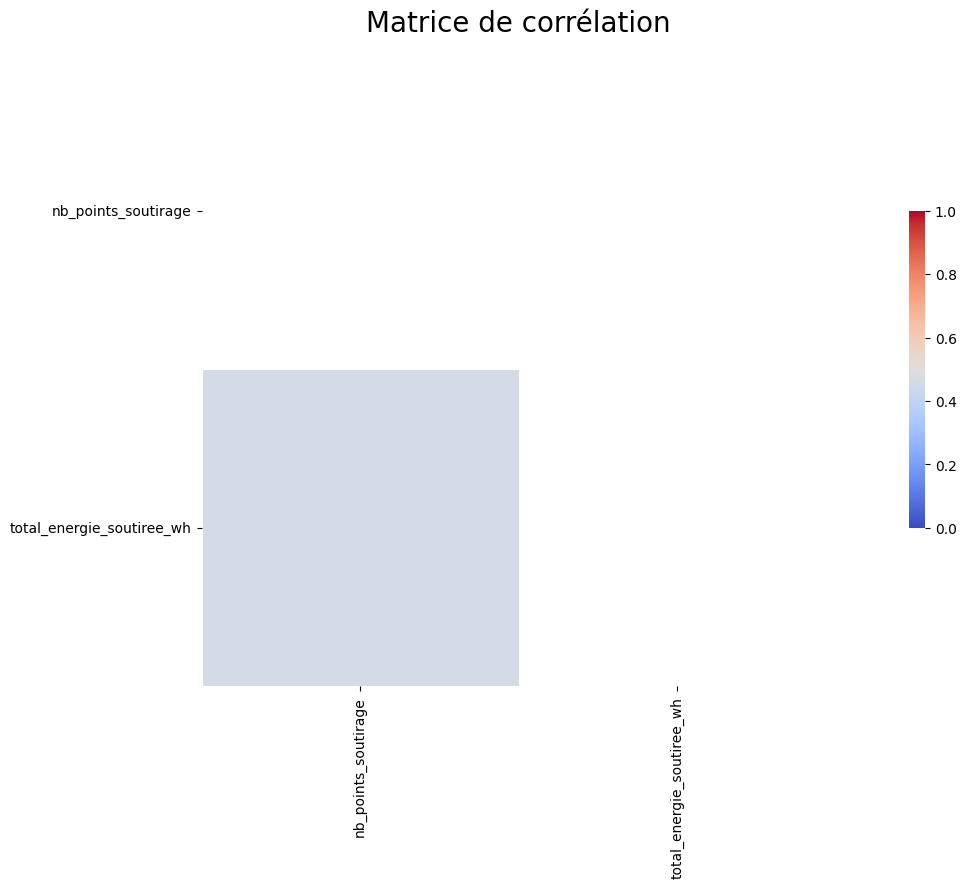

In [149]:
import numpy as np
import seaborn as sns

# Masque pour le triangle supérieur
mask = np.triu(np.ones_like(corr, dtype=bool))

# Configurer la heatmap
f, ax = plt.subplots(figsize=(15, 9))
sns.heatmap(
    np.abs(corr),
    annot=False,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    mask=mask,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    square=True,
    ax=ax,
)

# Configurer les étiquettes et le titre
plt.title("Matrice de corrélation", y=1.02, size=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()     

In [242]:
df_to_agg.shape

(8278, 6)

In [241]:
df_to_agg

,jour,secteur_activite,plage_de_puissance_souscrite,region,nb_points_soutirage,total_energie_soutiree_wh
0,2023-06-30,S1: Agriculture,P1: ]36-120] kVA,Auvergne-Rhône-Alpes,925.5,2.670014e+06
1,2023-06-30,S1: Agriculture,P1: ]36-120] kVA,Bourgogne-Franche-Comté,427.5,1.547332e+06
2,2023-06-30,S1: Agriculture,P1: ]36-120] kVA,Bretagne,1327.0,9.012052e+06
3,2023-06-30,S1: Agriculture,P1: ]36-120] kVA,Centre-Val de Loire,1863.5,1.705323e+07
4,2023-06-30,S1: Agriculture,P1: ]36-120] kVA,Hauts-de-France,764.0,6.186107e+06
...,...,...,...,...,...,...
8273,2025-10-02,S4: Non Affecté,P7: Total > 250 kVA,Hauts-de-France,0.0,0.000000e+00
8274,2025-10-02,S4: Non Affecté,P7: Total > 250 kVA,Normandie,0.0,0.000000e+00
8275,2025-10-02,S4: Non Affecté,P7: Total > 250 kVA,Occitanie,0.0,0.000000e+00
8276,2025-10-02,S4: Non Affecté,P7: Total > 250 kVA,Pays de la Loire,0.0,0.000000e+00


In [243]:
# Trier le DataFrame par ordre chronologique
df_to_agg_sorted = df_to_agg.sort_values(by='jour')

In [247]:
df_to_agg_sorted.head(60)

df_draw = df_to_agg_sorted[
    (df_to_agg_sorted["secteur_activite"] == "S4: Non Affecté") &
    (df_to_agg_sorted["region"] == "Auvergne-Rhône-Alpes") &
    (df_to_agg_sorted["plage_de_puissance_souscrite"] == "P1: ]36-120] kVA")
]

In [248]:
df_draw.shape

(27, 6)

In [ ]:
df_draw

In [ ]:
import matplotlib.pyplot as plt

# Exemple : Tracer 'plage_de_puissance_souscrite' en fonction de 'date'
plt.figure(figsize=(10, 6))
plt.plot(df_to_agg_sorted[:120]['jour'], df_to_agg_sorted[:120]['total_energie_soutiree_wh'], marker='o', linestyle='-')
plt.title("Evolution de consommation dans le temps")
plt.xlabel("Date")
plt.ylabel("Consommation")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [16]:
df.duplicated().sum()

np.int64(113378)

In [ ]:
import seaborn as sns
sns.countplot(x='nom_vacances', data=df)

<Axes: xlabel='vacances_zone_a', ylabel='count'>

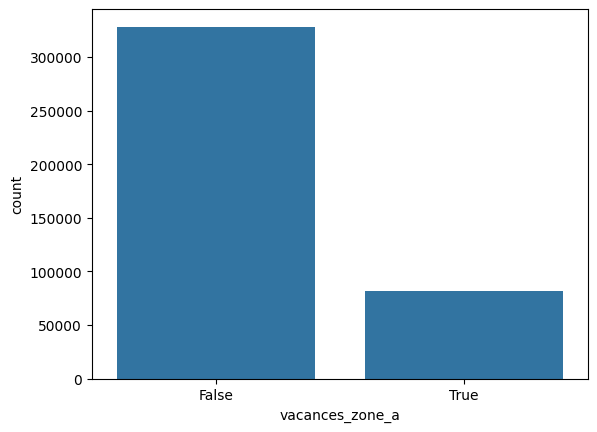

In [18]:
import seaborn as sns
sns.countplot(x='vacances_zone_a', data=df)

<Axes: xlabel='ville', ylabel='count'>

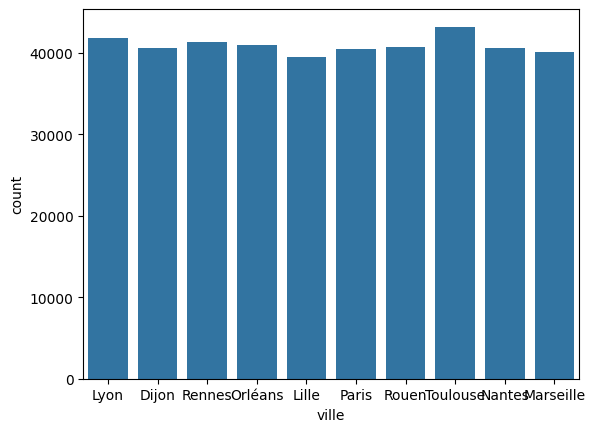

In [19]:
import seaborn as sns
sns.countplot(x='ville', data=df)

In [ ]:
df['zone_a'].value_counts()

In [12]:
df['zone_b'].value_counts()

zone_b
False    274996
True     183192
Name: count, dtype: int64

In [13]:
df['total_energie_soutiree_wh']

0         15727584.0
1          4151369.0
2          3873704.0
3          4680196.0
4          3803091.0
             ...    
549995       71750.0
549996           NaN
549997           NaN
549998       80500.0
549999      116166.0
Name: total_energie_soutiree_wh, Length: 550000, dtype: str

In [ ]:
df['total_energie_soutiree_wh']

In [21]:
df= df.drop_duplicates( subset=['total_energie_soutiree_wh'])

In [22]:
df.shape

(241929, 15)

In [23]:
df['jour_max_du_mois_0_1'].value_counts()

jour_max_du_mois_0_1
0    241929
Name: count, dtype: int64

In [35]:
df['semaine_max_du_mois_0_1'].value_counts()

semaine_max_du_mois_0_1
0    50000
Name: count, dtype: int64

In [24]:
df['plage_de_puissance_souscrite'].value_counts()

plage_de_puissance_souscrite
P3: Total ]36-250] kVA    54063
P1: ]36-120] kVA          49853
P2: ]120-250] kVA         47851
P4: ]250-1000] kVA        29469
P7: Total > 250 kVA       24924
P5: ]1000-2000] kVA       18309
P6: > 2000 kVA            17460
Name: count, dtype: int64

In [25]:
seuil = "0.0"
df.query("total_energie_soutiree_wh == @seuil")

,secteur_activite,jour_max_du_mois_0_1,semaine_max_du_mois_0_1,plage_de_puissance_souscrite,region,total_energie_soutiree_wh,nb_points_soutirage,date,ville,vacances_zone_a,vacances_zone_b,vacances_zone_c,temperature_2m_mean,relative_humidity_mean,precipitation_sum
97,S1: Agriculture,0,0,P4: ]250-1000] kVA,Auvergne-Rhône-Alpes,0.0,0,2024-09-30,Lyon,False,False,False,16.581251,63.248806,0.3


In [27]:
caster    = DataCaster()
transformer = Transformer()

In [28]:
df=caster.cast(df)

In [30]:
df=transformer.transform(df)

In [32]:
df.groupby("ville").agg({"relative_humidity_mean": 'mean'})

,relative_humidity_mean
ville,
Dijon,72.846464
Lille,76.662930
Lyon,73.618786
Marseille,66.518250
Nantes,75.884572
Orléans,74.898478
Paris,73.285250
Rennes,77.407772
Rouen,77.218831


In [33]:
df.groupby("ville").agg({"temperature_2m_mean": 'mean'})

,temperature_2m_mean
ville,
Dijon,12.923261
Lille,13.724353
Lyon,14.028147
Marseille,17.461356
Nantes,14.917393
Orléans,14.079101
Paris,14.437340
Rennes,14.244046
Rouen,13.537149


## Select Numerical Features

In [34]:
NUMERIC_COLS: list[str] = [
        "nb_points_soutirage",
        "total_energie_soutiree_wh",
        'temperature_2m_mean',
        'relative_humidity_mean',
        'precipitation_sum'   
    ]

    # Sélectionner uniquement les colonnes numériques
df_num = df[NUMERIC_COLS]

# Calculer la matrice de corrélation
corr = df_num.corr()

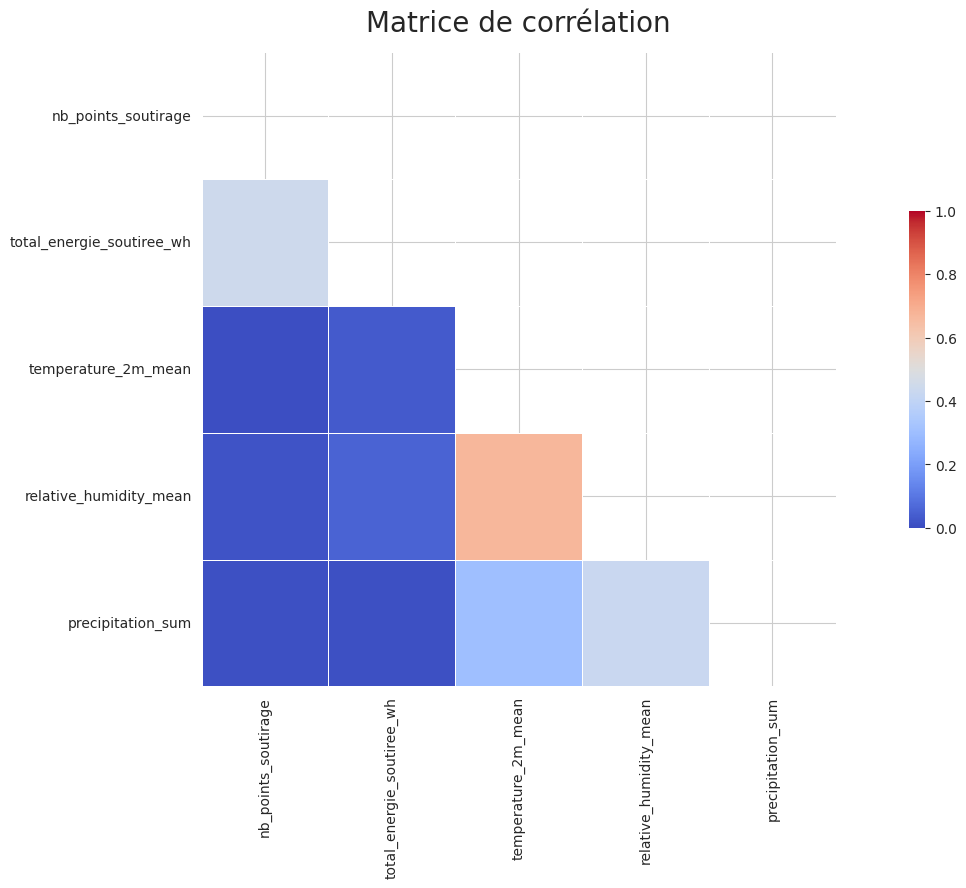

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Masque pour le triangle supérieur
mask = np.triu(np.ones_like(corr, dtype=bool))

# Configurer la heatmap
f, ax = plt.subplots(figsize=(15, 9))
sns.heatmap(
    np.abs(corr),
    annot=False,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    mask=mask,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    square=True,
    ax=ax,
)

# Configurer les étiquettes et le titre
plt.title("Matrice de corrélation", y=1.02, size=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()         

In [ ]:
STRING_COLS: list[str] = [
        "region",
        "Profil",
        "Plage de puissance souscrite",
        "Secteur activité",
        'jour_max_du_mois_0_1',
        'semaine_max_du_mois_0_1',
    ]

In [6]:
# Encoder les variables catégorielles
# Traiter le smissings values

## Distributions

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid") 

for col in NUMERIC_COLS:           # vos variables à explorer
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=df, y=col, color="steelblue", inner="quart")
    plt.title(f"Distribution de {col}")
    plt.xlabel("")
    plt.show()

In [252]:
from sklearn.feature_selection import chi2, mutual_info_classif, SelectKBest
import pandas as pd
import numpy as np

def select_categoricals_chi2(X_cat, y, k=10):
    """Chi² — pour cible binaire ou multiclasse."""
    selector = SelectKBest(chi2, k=k)
    selector.fit(X_cat, y)
    scores = pd.Series(selector.scores_, index=X_cat.columns)
    return scores.sort_values(ascending=False)

def select_categoricals_mutual_info(X_cat, y, k=10):
    """Information mutuelle — fonctionne avec n'importe quelle cible."""
    scores = mutual_info_classif(X_cat, y, discrete_features=True, random_state=42)
    return pd.Series(scores, index=X_cat.columns).sort_values(ascending=False)

## Select Categorical Features

In [253]:
df = pd.read_csv(
    path_file,
    sep=";",
    dtype=str,
)

In [265]:
from sklearn.preprocessing import OrdinalEncoder

# Colonnes catégorielles à tester
cat_cols = ['secteur_activite', 'plage_de_puissance_souscrite', 'region']
X_cat = df[cat_cols]

df = df.dropna(subset=["total_energie_soutiree_wh"])
y = df["total_energie_soutiree_wh"]

# Encodage en nombres
X_encoded = pd.DataFrame(
    OrdinalEncoder().fit_transform(X_cat),
    columns=cat_cols
)

scores = select_categoricals_chi2(X_encoded, y)
print(scores)

/media/frederic/DD_Stockage_2To/main_code/jedha/Jenedai/.venv/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=10 is greater than n_features=3. All the features will be returned.
  warnings.warn(


region                          660207.780128
plage_de_puissance_souscrite    510622.760028
secteur_activite                198674.107619
dtype: float64


In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

#Détermination des colonnes cathegorielles et numériques
# Encodage One-Hot des variables catégorielles
one_hot_enc = pd.get_dummies(df, columns=['Geography', 'Gender','HasCrCard','IsActiveMember'])

# Concaténer les colonnes encodées avec les autres colonnes du DataFrame
encoded_df = pd.concat([df, one_hot_enc], axis=1)
# Supprimer les colonnes d'origine
encoded_df = encoded_df.drop(['Geography', 'Gender','HasCrCard','IsActiveMember'], axis=1)


In [ ]:
print(encoded_df.columns,end="\n\n")
print(num_cols,end="\n\n")


In [47]:
#standardiser

In [ ]:
#encoder

In [ ]:
from sklearn.preprocessing import OneHotEncoder
oh_encoder = OneHotEncoder(sparse_output=False, drop='first',handle_unknown='ignore')
onehot_preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', oh_encoder, cols_to_category),
    ],remainder = 'passthrough', verbose_feature_names_out= False).set_output(transform='pandas')
  

In [ ]:
#gerer las valeurs manquantes

In [ ]:
ajouter des variables = feature engeneering